In [25]:
import utils_inverse
import numpy as np
import pickle
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Evaluate emulator on zonal outputs from MESM

## 1. Generate initial parameters and create baseline emulator

In [2]:
agents = ["CO2"]
scenarios_eval = {'Tier 1':['historical','H-ext','L','M','ML','VLHO','VLLO-ext'],
                  'Tier 2':['H-ext-OS','M-ext','ML-ext','L-ext','VLHO-ext'],
                  'DECK':['1pctCO2','2xCO2'],
                  'CS3':['AA','CT','historical']}
eval_dir = 'data/MESM/emis_driven/zonal_data_mean/'

(eval_emis_sets,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_CS3_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, DECK=False, CS3=True, DAMIP=False, GeoMIP=False)

(eval_targets_sets,
targets_dict_tier1,
targets_dict_tier2,
targets_dict_DECK,
targets_dict_CS3,
output_dim,
lat_coords) = utils_inverse.generate_target_data(scenarios_eval, data_dir=eval_dir)

In [3]:
emis_path = '/Users/chriswomack/Documents/PhD/Project 2/data/MESM/emis_driven'
emis_1pct_path = f'{emis_path}/1PRCO2/carbemiss.txt'
emis_1pct = np.loadtxt(emis_1pct_path, usecols=(2,), skiprows=2)
emis_mat_1pct = np.zeros((5, len(emis_1pct)))
emis_mat_1pct[0,:] = emis_1pct

emis_2xCO2_path = f'{emis_path}/2xCO2/implco2emiss.3100.25.txt'
emis_2xCO2 = np.loadtxt(emis_2xCO2_path, usecols=(2,))
emis_mat_2xCO2 = np.zeros((5, len(emis_2xCO2)))
emis_mat_2xCO2[0,:] = emis_2xCO2

emis_dict_DECK = {'1pctCO2': emis_mat_1pct, '2xCO2': emis_mat_2xCO2}

In [4]:
eval_emis_sets['DECK'] = emis_dict_DECK.copy()

In [63]:
eval_emis_sets['optimized'] = eval_emis_opt_sets['optimized'].copy()
eval_targets_sets['optimized'] = eval_targets_opt_sets['optimized'].copy()

In [64]:
results_baseline, preds_baseline, truths_baseline, paramsk_baseline, stats_X_baseline = utils_inverse.generate_and_eval_emulator_vector(
    emis_dict_train=emis_dict_tier1_JAX,
    targets_dict_train=targets_dict_tier1,
    eval_emis_sets=eval_emis_sets,
    eval_targets_sets=eval_targets_sets,
    output_dim=output_dim,
    lat_coords=lat_coords,
    hidden_sizes=[16],
    K=400,
    lr=1e-1,
    weight_decay=1e-2,
    verbose=True
)


Tier 1 Mean Global NRMSE: 0.0756

Tier 2 Mean Global NRMSE: 0.1142

CS3 Mean Global NRMSE: 0.0823

DECK Mean Global NRMSE: 0.1760

optimized Mean Global NRMSE: 0.0786


In [66]:
path = 'data/plotting/baseline_co2_only_MESM.pkl'
with open(path, "wb") as f:
  pickle.dump(results_baseline, f)

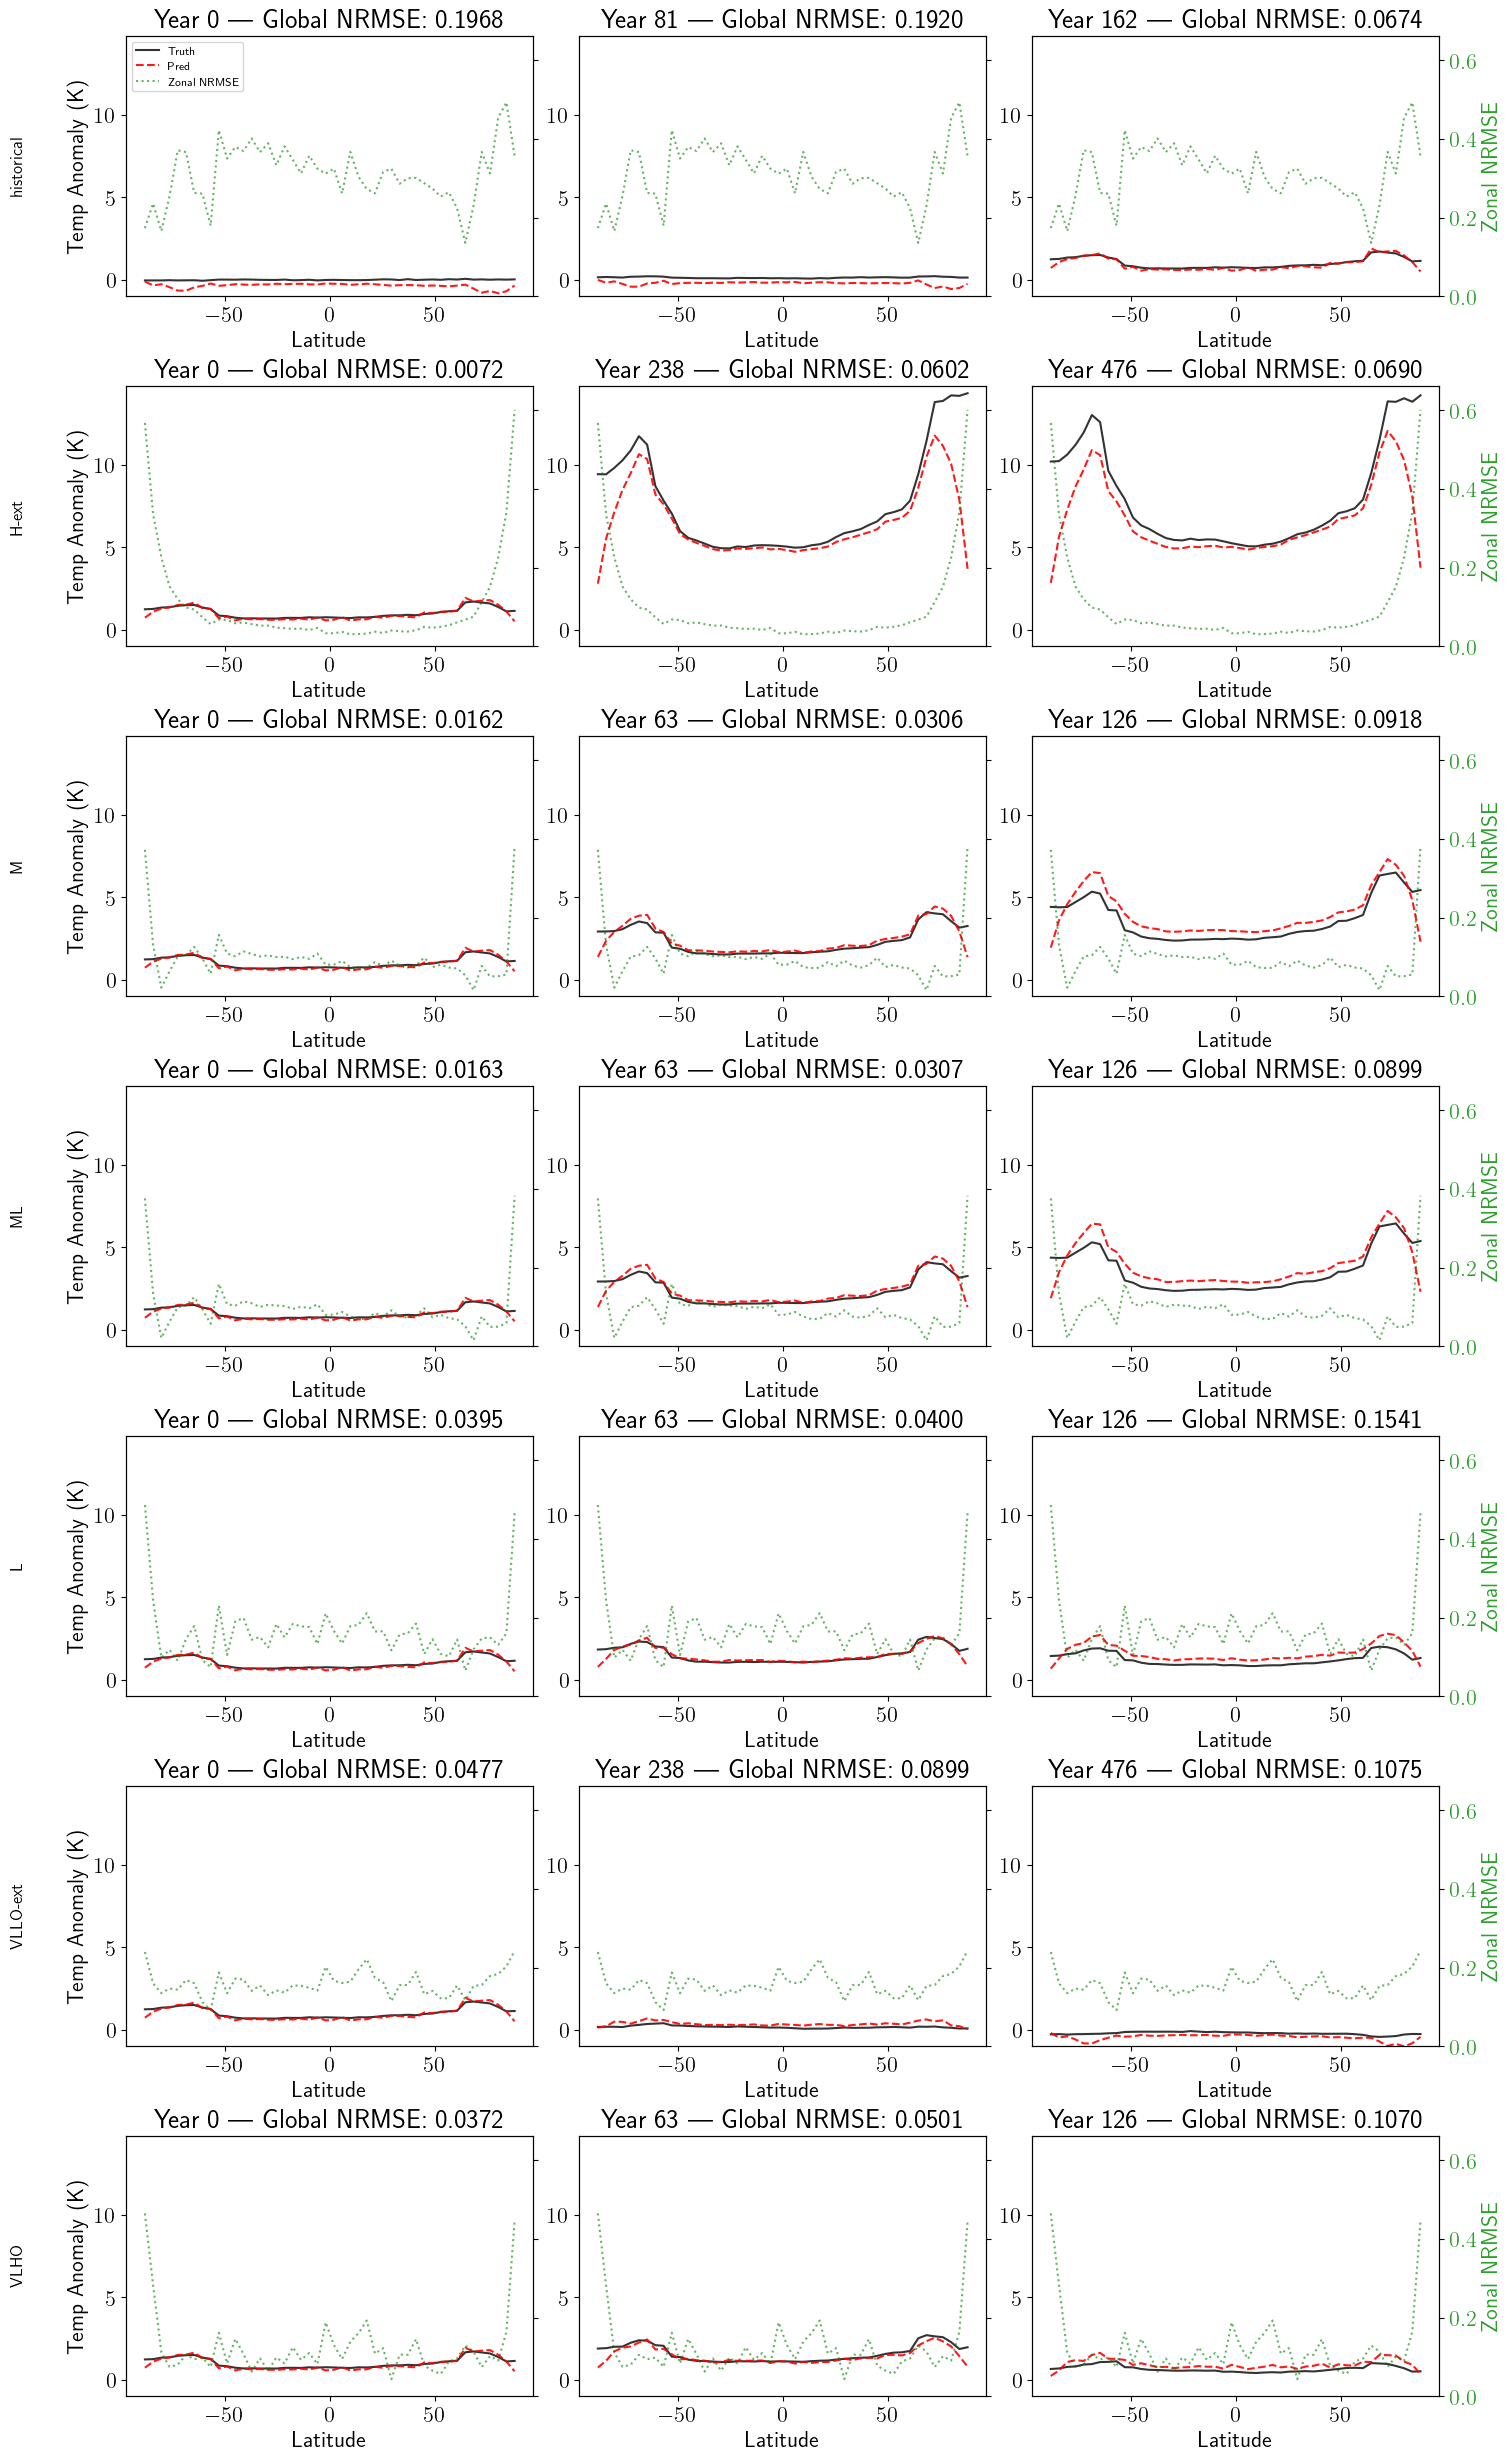

In [39]:
fig = utils_inverse.plot_zonal_predictions(results_baseline, preds_baseline, truths_baseline, lat_coords, eval_set='Tier 1')

## 2. Evaluate optimal emulators

In [85]:
group = 'all'
ICs = ['constant','sine']
emis_dict_opt = {}
for IC in ICs:
    opt_path = f"checkpoints/co2/inverse_{IC}_{group}_co2_only_MESM.pkl"
    with open(opt_path, "rb") as f:
        res = pickle.load(f)
    co2_array = res['U_traj'][-1]['CO2']
    emis_dict_opt[group + '_' + IC] = np.zeros((5, len(co2_array)))
    emis_dict_opt[group + '_' + IC][0,:] = co2_array.copy()

eval_emis_opt_sets = {'optimized':emis_dict_opt.copy()}

scenarios_train = {'optimized':[group + '_' + IC for IC in ICs]}

(eval_targets_opt_sets,
targets_dict_opt,
_,
_) = utils_inverse.generate_target_data(scenarios_train, data_dir=eval_dir, opt=True)

for key in eval_targets_sets:
    eval_targets_opt_sets[key] = eval_targets_sets[key].copy()
    eval_emis_opt_sets[key] = eval_emis_sets[key].copy()

In [86]:
results_opt, preds_opt, truths_opt, params_opt, stats_X_opt = utils_inverse.generate_and_eval_emulator_vector(
    emis_dict_train=emis_dict_opt,
    targets_dict_train=targets_dict_opt,
    eval_emis_sets=eval_emis_opt_sets,
    eval_targets_sets=eval_targets_opt_sets,
    output_dim=output_dim,
    lat_coords=lat_coords,
    hidden_sizes=[16],
    lr=1e-1,
    weight_decay=1e-2,
    K=400,
    verbose=True,
)


optimized Mean Global NRMSE: 0.0337

Tier 1 Mean Global NRMSE: 0.0850

Tier 2 Mean Global NRMSE: 0.0709

DECK Mean Global NRMSE: 0.2057

CS3 Mean Global NRMSE: 0.1173


In [76]:
path = f'data/plotting/optimal_co2_only_MESM_{IC}.pkl'
with open(path, "wb") as f:
  pickle.dump(results_opt, f)

In [87]:
for key in results_baseline.keys():
  print('Eval set: ', key)
  for scen in results_baseline[key].keys():
    old = results_baseline[key][scen]['global']
    new = results_opt[key][scen]['global']
    pctChange = 100 * (old - new) / old
    print('\tScen:', scen, 'Change:', pctChange)
    print('\t\tRaw base:', old, 'Raw opt:', new)

Eval set:  Tier 1
	Scen: historical Change: -0.2490775745515058
		Raw base: 0.1624438613653183 Raw opt: 0.16284847259521484
	Scen: H-ext Change: 53.09378338246415
		Raw base: 0.06323207914829254 Raw opt: 0.029659776017069817
	Scen: M Change: 6.311125491442204
		Raw base: 0.04499489814043045 Raw opt: 0.04215521365404129
	Scen: ML Change: 4.271613833392128
		Raw base: 0.044806595891714096 Raw opt: 0.04289263114333153
	Scen: L Change: -33.30990471608022
		Raw base: 0.08011781424283981 Raw opt: 0.1068049818277359
	Scen: VLLO-ext Change: -63.15664819105803
		Raw base: 0.0772603452205658 Raw opt: 0.12605538964271545
	Scen: VLHO Change: -64.73026600701726
		Raw base: 0.06183202564716339 Raw opt: 0.1018560603260994
	Scen: mean Change: -12.361787644682135
		Raw base: 0.07564655706744927 Raw opt: 0.08499782381264064
Eval set:  Tier 2
	Scen: H-ext-OS Change: 51.93852730238528
		Raw base: 0.061009056866168976 Raw opt: 0.029321851208806038
	Scen: M-ext Change: 72.89844069119523
		Raw base: 0.128446

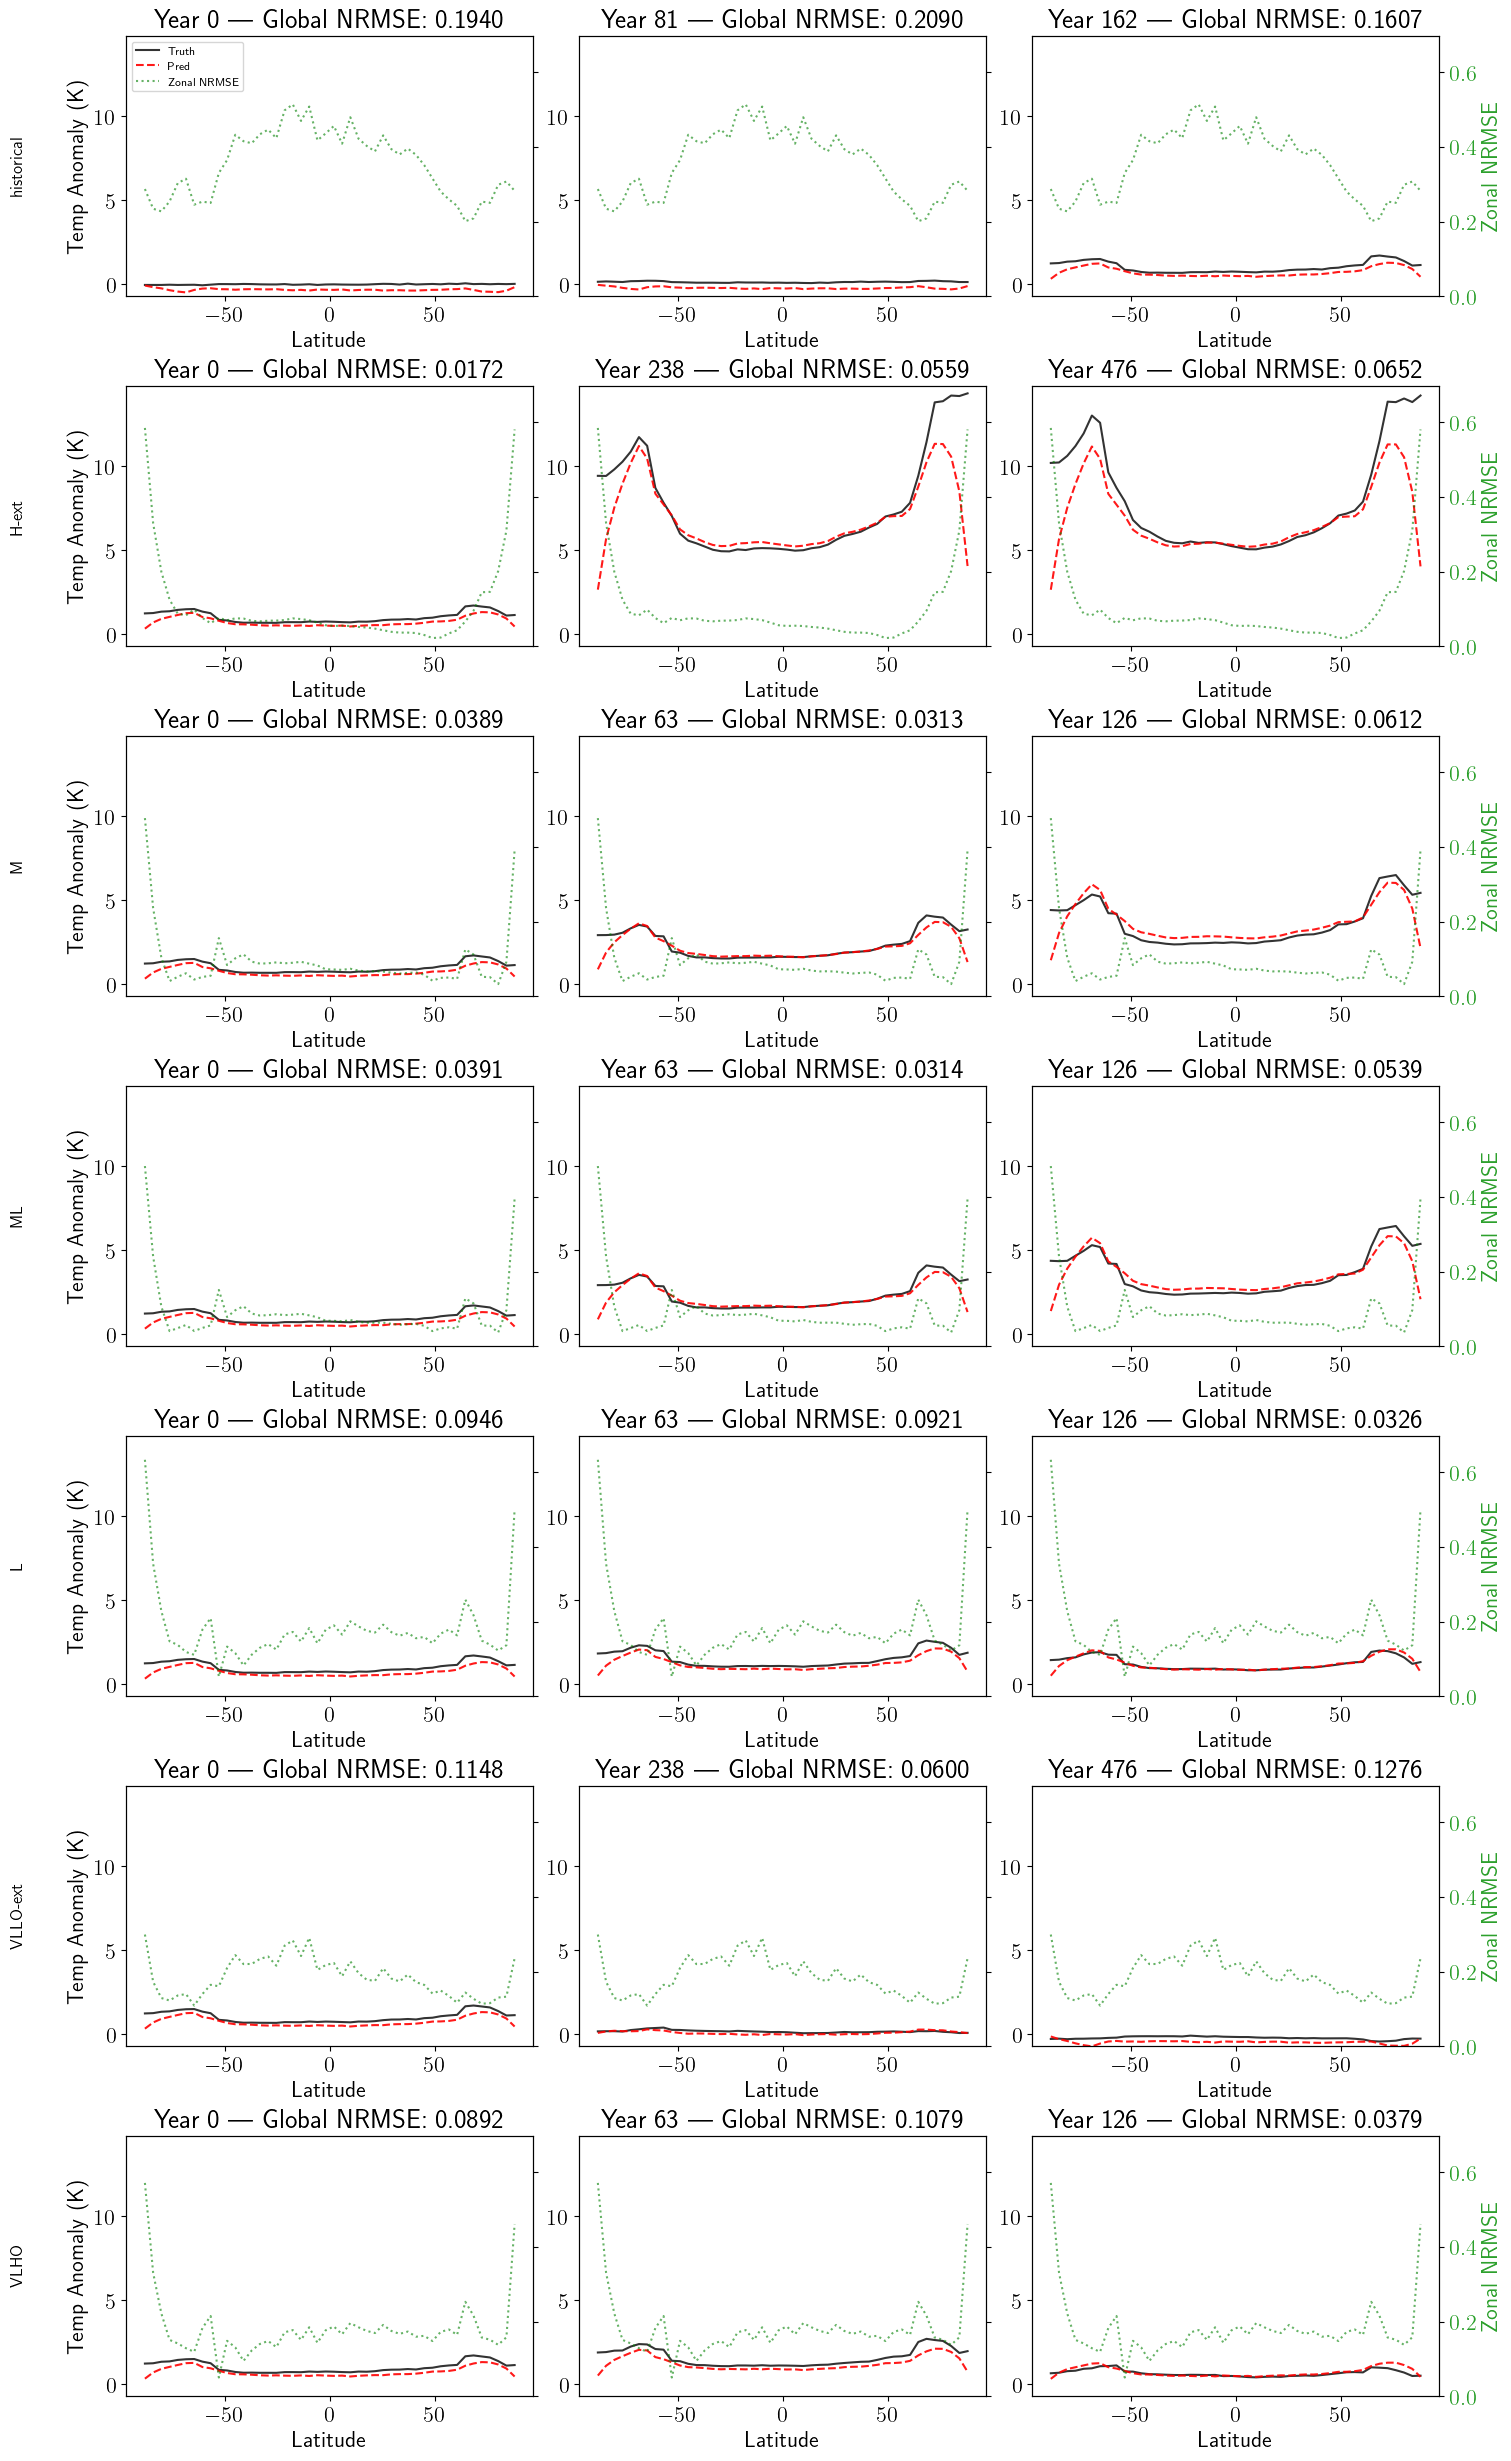

In [57]:
fig = utils_inverse.plot_zonal_predictions(results_opt, preds_opt, truths_opt, lat_coords, eval_set='Tier 1')

In [8]:
import pandas as pd
def run_hyperparameter_sweep(
    n_trials=20,
    emis_train_opt=None,
    targets_train_opt=None,
    emis_train_base=None,
    targets_train_base=None,
    eval_emis=None,
    eval_targets=None,
    output_dim=None,
    lat_coords=None,
    compare=False
):
    results_log = []

    # 1. Define Search Space (Log-Uniform for rates/decays)
    for i in range(n_trials):
        # Sample Hyperparams
        hparams = {
            # Network Capacity
            # 50% chance of 1 layer, 50% chance of 2 layers
            'hidden_sizes': [int(np.random.choice([16, 32, 48]))] * np.random.choice([1, 2]),

            # Optimization
            'lr': 10 ** np.random.uniform(-3, -1),  # 0.001 to 0.1
            'weight_decay': 10 ** np.random.uniform(-3, 0), # 0.0001 to 0.1
            'K': int(np.random.choice([400, 800, 1200])),

            # Seed (good to vary this to ensure stability)
            'key_seed': int(np.random.randint(0, 1000))
        }

        if (i + 1) % 10 == 0 or i == 0:
            print(f"Trial {i+1}/{n_trials}")

        # 2. Run Training & Eval
        # We assume you have loaded your data dictionaries already
        res_opt, _, _, _, _ = utils_inverse.generate_and_eval_emulator_vector(
            emis_dict_train=emis_train_opt,
            targets_dict_train=targets_train_opt,
            eval_emis_sets=eval_emis,
            eval_targets_sets=eval_targets,
            output_dim=output_dim,
            lat_coords=lat_coords,

            # Inject Hyperparams
            hidden_sizes=hparams['hidden_sizes'],
            lr=hparams['lr'],
            weight_decay=hparams['weight_decay'],
            K=hparams['K'],
            key_seed=hparams['key_seed'],

            verbose=False
        )

        if compare:
            res_base, _, _, _, _ = utils_inverse.generate_and_eval_emulator_vector(
                emis_dict_train=emis_train_base,
                targets_dict_train=targets_train_base,
                eval_emis_sets=eval_emis,
                eval_targets_sets=eval_targets,
                output_dim=output_dim,
                lat_coords=lat_coords,

                # Inject Hyperparams
                hidden_sizes=hparams['hidden_sizes'],
                lr=hparams['lr'],
                weight_decay=hparams['weight_decay'],
                K=hparams['K'],
                key_seed=hparams['key_seed'],

                verbose=False
            )

        # 3. Extract a single scalar metric to minimize
        # We want to generalize to Tier 1 (Baseline), so we use that error.
        # DO NOT use the training error (results_out[train_label]).

        weights = [7, 5, 2, 2]
        val_metrics_opt = [res_opt['Tier 1']['mean']['global'],
                       res_opt['Tier 2']['mean']['global'],
                       res_opt['DECK']['mean']['global'],
                       res_opt['CS3']['mean']['global']]
        val_opt = np.average(val_metrics_opt, weights=weights)

        if compare:
            val_metrics_base = [res_base['Tier 1']['mean']['global'],
                        res_base['Tier 2']['mean']['global'],
                        res_base['DECK']['mean']['global'],
                        res_base['CS3']['mean']['global']]
            val_base = np.average(val_metrics_base, weights=weights)

        # Log it
        record = hparams.copy()
        record['hidden_sizes'] = str(record['hidden_sizes']) # make hashable for pandas
        record['val_opt'] = val_opt
        if compare:
            record['val_base'] = val_base
            record['pct_change'] = 100 * (val_base - val_opt) / val_base
        results_log.append(record)

        #print(f"   -> Val NRMSE: {val_metric:.5f}")

    # 4. Analyze
    df = pd.DataFrame(results_log)
    if compare:
        best_row = df.loc[df['pct_change'].idxmax()]
    else:
        best_row = df.loc[df['val_opt'].idxmin()]

    print("\n--- BEST HYPERPARAMETERS ---")
    print(best_row)

    return df

In [9]:
df = run_hyperparameter_sweep(
    n_trials=50,
    emis_train_opt=emis_dict_opt,
    targets_train_opt=targets_dict_opt,
    emis_train_base=emis_dict_tier1_JAX,
    targets_train_base=targets_dict_tier1,
    eval_emis=eval_emis_opt_sets,
    eval_targets=eval_targets_opt_sets,
    output_dim=output_dim,
    lat_coords=lat_coords,
    compare=False
)

Trial 1/50
Trial 10/50
Trial 20/50
Trial 30/50
Trial 40/50
Trial 50/50

--- BEST HYPERPARAMETERS ---
hidden_sizes    [48, 48]
lr              0.010445
weight_decay    0.001182
K                    400
key_seed             775
val_opt         0.231381
Name: 6, dtype: object


In [10]:
df.sort_values(by=["val_opt"])

,hidden_sizes,lr,weight_decay,K,key_seed,val_opt
6,"[48, 48]",0.010445,0.001182,400,775,0.231381
47,[32],0.004782,0.013056,1200,2,0.252978
32,[48],0.006122,0.002263,800,28,0.271872
40,"[16, 16]",0.008819,0.005456,400,732,0.277931
9,[32],0.081063,0.005113,1200,906,0.278383
0,"[32, 32]",0.003796,0.002439,800,561,0.279821
19,[32],0.004107,0.116411,1200,351,0.285738
44,[32],0.025451,0.268636,400,442,0.286206
5,[16],0.004530,0.004946,1200,125,0.287030
12,[48],0.009897,0.001222,400,404,0.290539
